In [8]:
!pip install numpy pandas matplotlib seaborn sqlite3

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


In [101]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### 1. Connecting SQL

In [102]:
conn = sqlite3.connect('customer_churn.db')

sql_query="""
    select name
    from sqlite_master
    where type='table';
"""

tables=pd.read_sql(sql_query,conn);

#creating table dataframe for each table
for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe: df_{table_name}")
conn.close()
    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [103]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()



Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


### 2. Data Cleaning

In [104]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [105]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [106]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [107]:
# a. rename col - name

df_db_customer.rename(columns={'name': 'customer_name'},inplace=True)

In [108]:
# b. drop columns - interest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:],axis=1)
df_db_customer.columns[-2:]
#df_db_customer.tail()
df_db_customer.drop(columns=['interests','pincode'],inplace=True)
df_db_customer.tail()



,customerid,customer_name,country,state,gender,dob
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00


In [109]:
df_db_customer.info()


<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [110]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()



<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [111]:
# d. data standardization - gender

#df_db_customer['gender'].unique()
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})


In [112]:
df_db_customer['gender'].unique()


<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [113]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [114]:
df_db_customer['country'].fillna('Unknown Country')

0               India
1               India
2               India
3               India
4               India
5     Unknown Country
6               India
7               India
8     Unknown Country
9               Nepal
10              India
11              India
12    Unknown Country
13              India
14              India
15              India
16              India
17              India
18              India
19              India
20              India
Name: country, dtype: str

In [115]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [116]:
# country and state - unique value pair

state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [117]:
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [118]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [119]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [120]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [121]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)

df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [122]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [124]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [125]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [126]:
df_db_support.describe()

,csat_score
count,9.000000
mean,40.555556
std,31.666667
min,10.000000
25%,20.000000
50%,30.000000
75%,60.000000
max,90.000000


In [127]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [128]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


### 3. Feature engineering and data analysis

In [130]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [131]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [132]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [135]:
(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                    .merge(df_db_support,on='customerid',how='left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [ ]:
#First fix support tabel duplicates then merge

In [138]:
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                    .merge(df_db_support,on='customerid',how='left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [139]:
df_db_subscription.shape

(21, 12)

In [140]:
df.shape

(23, 20)

In [141]:
df_db_subscription['customerid'].nunique()

21

In [142]:
df_db_customer['customerid'].nunique()

21

In [143]:
df_db_support['customerid'].nunique()

7

In [145]:
df_db_support['customerid'].size

9

In [146]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [148]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [149]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [234]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [235]:
df_db_support['customerid'].size

7

In [236]:
#Merge df

In [237]:
df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                    .merge(df_db_support,on='customerid',how='left'))

In [238]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [239]:
df.shape

(21, 21)

In [240]:
df.to_csv('exported_data.csv',index=False)

### Data Analysis

### 1. Churn Rate

In [241]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [242]:
churn_rate=df['churn_flag'].mean()*100
print("Chrun rate = ",round(churn_rate,2),"%")

Chrun rate =  28.57 %


### 2. Retention Rate

In [243]:
retention_rate=100-churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [244]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


### 3. Churn by plan type

In [245]:
churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index()
print(churn_by_plan)

  plan_type  churn_flag
0     Basic       60.00
1   Premium       14.29
2  Standard       22.22


### 4.a. Churn by state

In [246]:
churn_by_state=df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index()
print(churn_by_state)

           state  churn_flag
0          Delhi       25.00
1      Karnataka      100.00
2      Kathmandu        0.00
3    Maharashtra        0.00
4      Meghalaya       66.67
5       Nagaland        0.00
6      Rajasthan        0.00
7      Telangana       50.00
8  Uttar Pradesh        0.00


### 4.a. Churn by subscription type + sum(revenue & count of users)

In [247]:
churn_by_subscription_type=df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index()
print(churn_by_subscription_type)


  subscription_type  churn_flag
0           Organic        0.00
1              Paid       16.67
2          Refferal       83.33


### 5. ARPU - Average Revenue Per User

In [248]:
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [249]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

### 6. Average customer Tenure
### Count of days users has used our service : cancelllation date else current date 

In [250]:
today= pd.Timestamp.today()
pd.Timestamp.today()

Timestamp('2026-09-26 02:19:55.033134')

In [251]:
df['Tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
df.head()

avg_tenure=df['Tenure_days'].mean()
print("Avg Tenure Days) = ",round(avg_tenure),0)


Avg Tenure Days) =  1547 0


### 7. Revenue at risk - revenue lost from churn users

In [252]:
revenue_at_risk=df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print(f"Revenue at risk = {revenue_at_risk} Lakhs revenue lost from churn users")

Revenue at risk = 73.94 Lakhs revenue lost from churn users


### 8. Escalation rate

In [257]:
escalation_rate=(df['escalations']=='Y').mean()*100
df['escalations']
print("Escalation Rate = ",round(escalation_rate,2),"%")

Escalation Rate =  19.05 %


### 9. Avg complaints per user

In [258]:
avg_complaints=df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complaints per user = ",round(avg_complaints,2))

Avg complaints per user =  0.43


### 10. Correlation Escalation Vs Churn

In [259]:

df['escalations']=np.where(df['escalations']=='Y',1,0) #encoding string into int type

corr_df= df[['escalations','churn_flag']].dropna()
corr_df

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Corrrelation between escalation vs churn is = ", round(correlation,2))



Corrrelation between escalation vs churn is =  0.77


### 11. Churn risk - create a column using existing column

In [260]:


df['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [262]:
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['Low', 'Mid', 'High']

df['churn_risk']=np.select(conditions, choices, default='unknown')

df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
16,Mid,62
17,Low,27
18,High,99
19,Low,7
20,Low,47


In [193]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days'],
      dtype='str')

## 4. Visualization using Matplotlib

In [263]:
df_visual=df.copy()

In [264]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days', 'churn_risk'],
      dtype='str')

### 4.1 Monthly Churn Trend (Trend Series KPI)

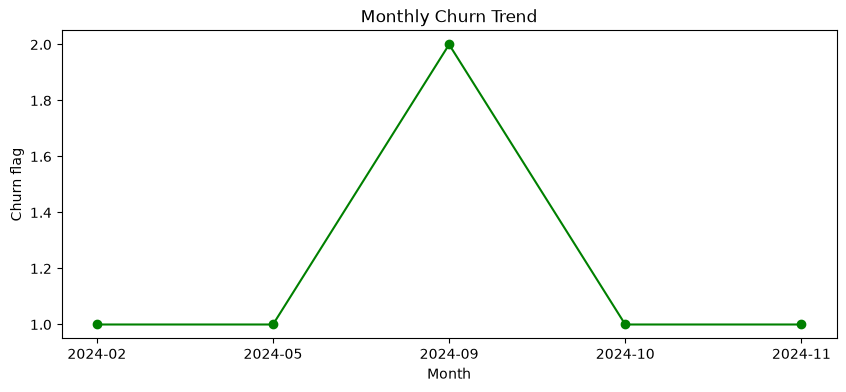

In [270]:
df_visual['cancellation_month']= df_visual['cancellation_date'].dt.to_period("M")

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize={10,4})
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color='green',marker='o')

plt.title("Monthly Churn Trend")

plt.xlabel('Month')
plt.ylabel('Churn flag')
plt.show()

### 4.2 Churn by plan type

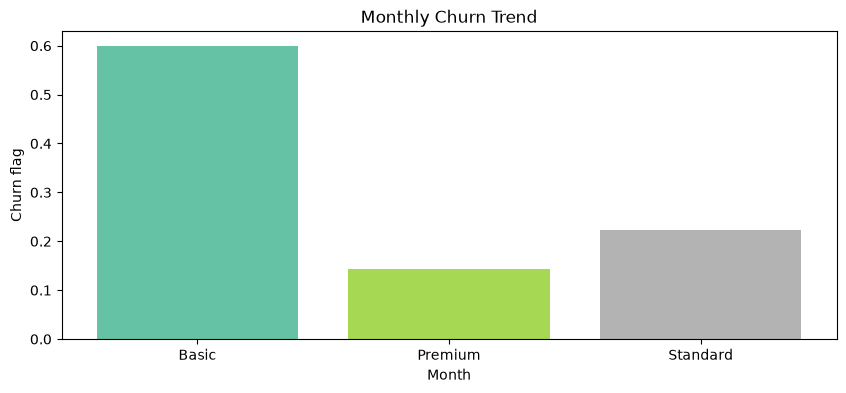

In [272]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize={10,4})
plt.bar(churn_plan.index,churn_plan.values,color=colors)

plt.title("Monthly Churn Trend")

plt.xlabel('Month')
plt.ylabel('Churn flag')
plt.show()

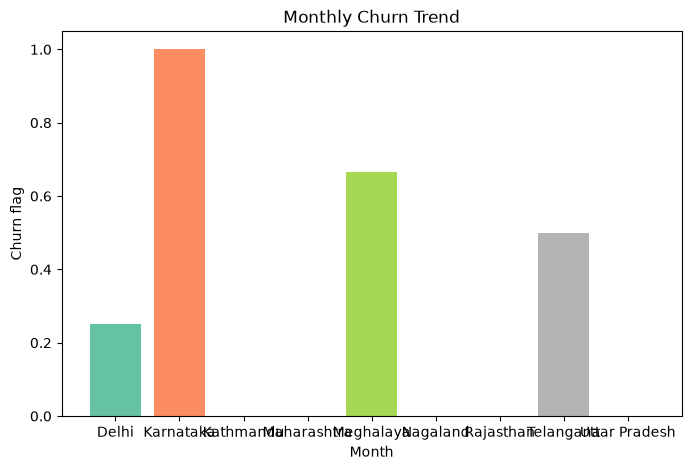

In [279]:
### 4.3 Churn by State

churn_state = df_visual.groupby('state')['churn_flag'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_state)))

plt.figure(figsize={8,5})
plt.bar(churn_state.index,churn_state.values,color=colors)

plt.title("Monthly Churn Trend")

plt.xlabel('Month')
plt.ylabel('Churn flag')
plt.show()

In [280]:
# Visualizations using seaborn

In [281]:
# encoding - conver string to numerical to find corr between features


In [294]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'Tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [295]:
# incorrect way of encoding

df_encoded=df_visual[['plan_type', 'contract_type','churn_risk', 'churn_score',
       'churn_flag','escalations']]
df_encoded

catogorical_cols=['plan_type', 'contract_type','churn_risk']

for col in catogorical_cols:
    df_encoded[col]= df_encoded[col].astype('category').cat.codes

In [296]:
df_encoded[['plan_type', 'contract_type','churn_risk', 'churn_score',
       'churn_flag','escalations']]

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,2,0,1,12,0,0
1,1,0,0,91,1,1
2,0,1,1,34,0,0
3,1,0,1,8,0,0
4,2,1,0,88,1,1
5,2,0,1,22,0,0
6,0,1,0,79,1,0
7,1,0,1,5,0,0
8,2,1,1,34,0,0
9,0,0,1,41,0,0


In [297]:
# Heatmap (correlation matrix)

df_encoded.head()

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,2,0,1,12,0,0
1,1,0,0,91,1,1
2,0,1,1,34,0,0
3,1,0,1,8,0,0
4,2,1,0,88,1,1


<Axes: >

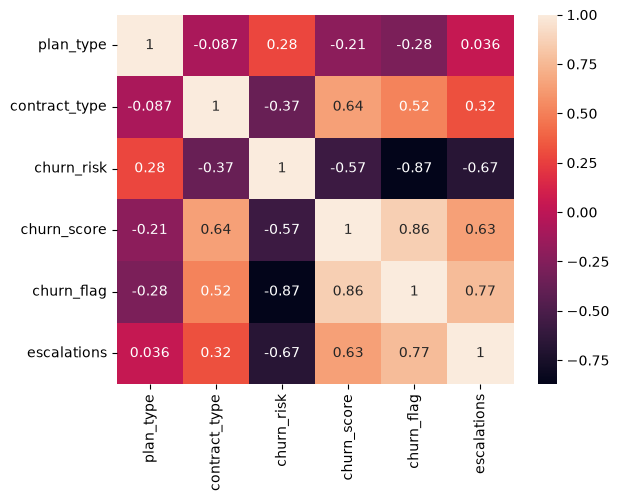

In [299]:
sns.heatmap(df_encoded.corr(),annot=True)

In [300]:
# correct method of encoding based on priority

In [305]:
df_visual['churn_risk'].unique()

<StringArray>
['Low', 'High', 'Mid']
Length: 3, dtype: str

In [309]:
df_encoded=df_visual[['plan_type', 'contract_type','churn_risk', 'churn_score',
       'churn_flag','escalations']]
df_encoded
order_mapping={
    'plan_type':['Basic','Standard', 'Premium'],
    'contract_type':['Annual', 'Monthly'],
    'churn_risk':['Low', 'Mid', 'High']
}

for col,order in order_mapping.items():
    df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'), categories=order,ordered=True).codes

In [310]:
df_encoded.head()

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,1,0,0,12,0,0
1,2,0,2,91,1,1
2,0,1,0,34,0,0
3,2,0,0,8,0,0
4,1,1,2,88,1,1


In [311]:
df_visual[['plan_type', 'contract_type','churn_risk', 'churn_score',
       'churn_flag','escalations']]

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,Standard,Annual,Low,12,0,0
1,Premium,Annual,High,91,1,1
2,Basic,Monthly,Low,34,0,0
3,Premium,Annual,Low,8,0,0
4,Standard,Monthly,High,88,1,1
5,Standard,Annual,Low,22,0,0
6,Basic,Monthly,High,79,1,0
7,Premium,Annual,Low,5,0,0
8,Standard,Monthly,Low,34,0,0
9,Basic,Annual,Low,41,0,0


<Axes: >

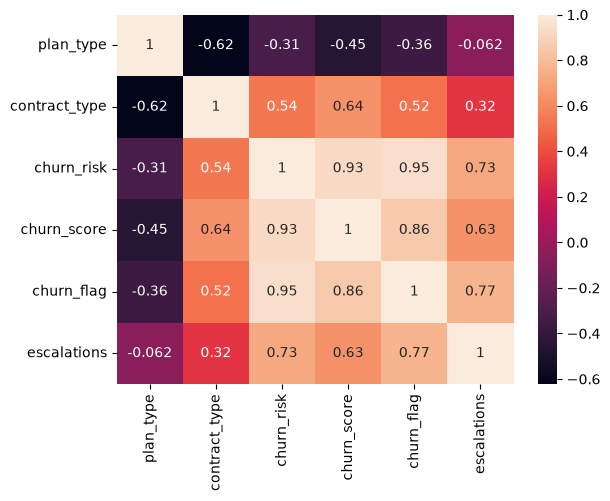

In [312]:
sns.heatmap(df_encoded.corr(),annot=True)

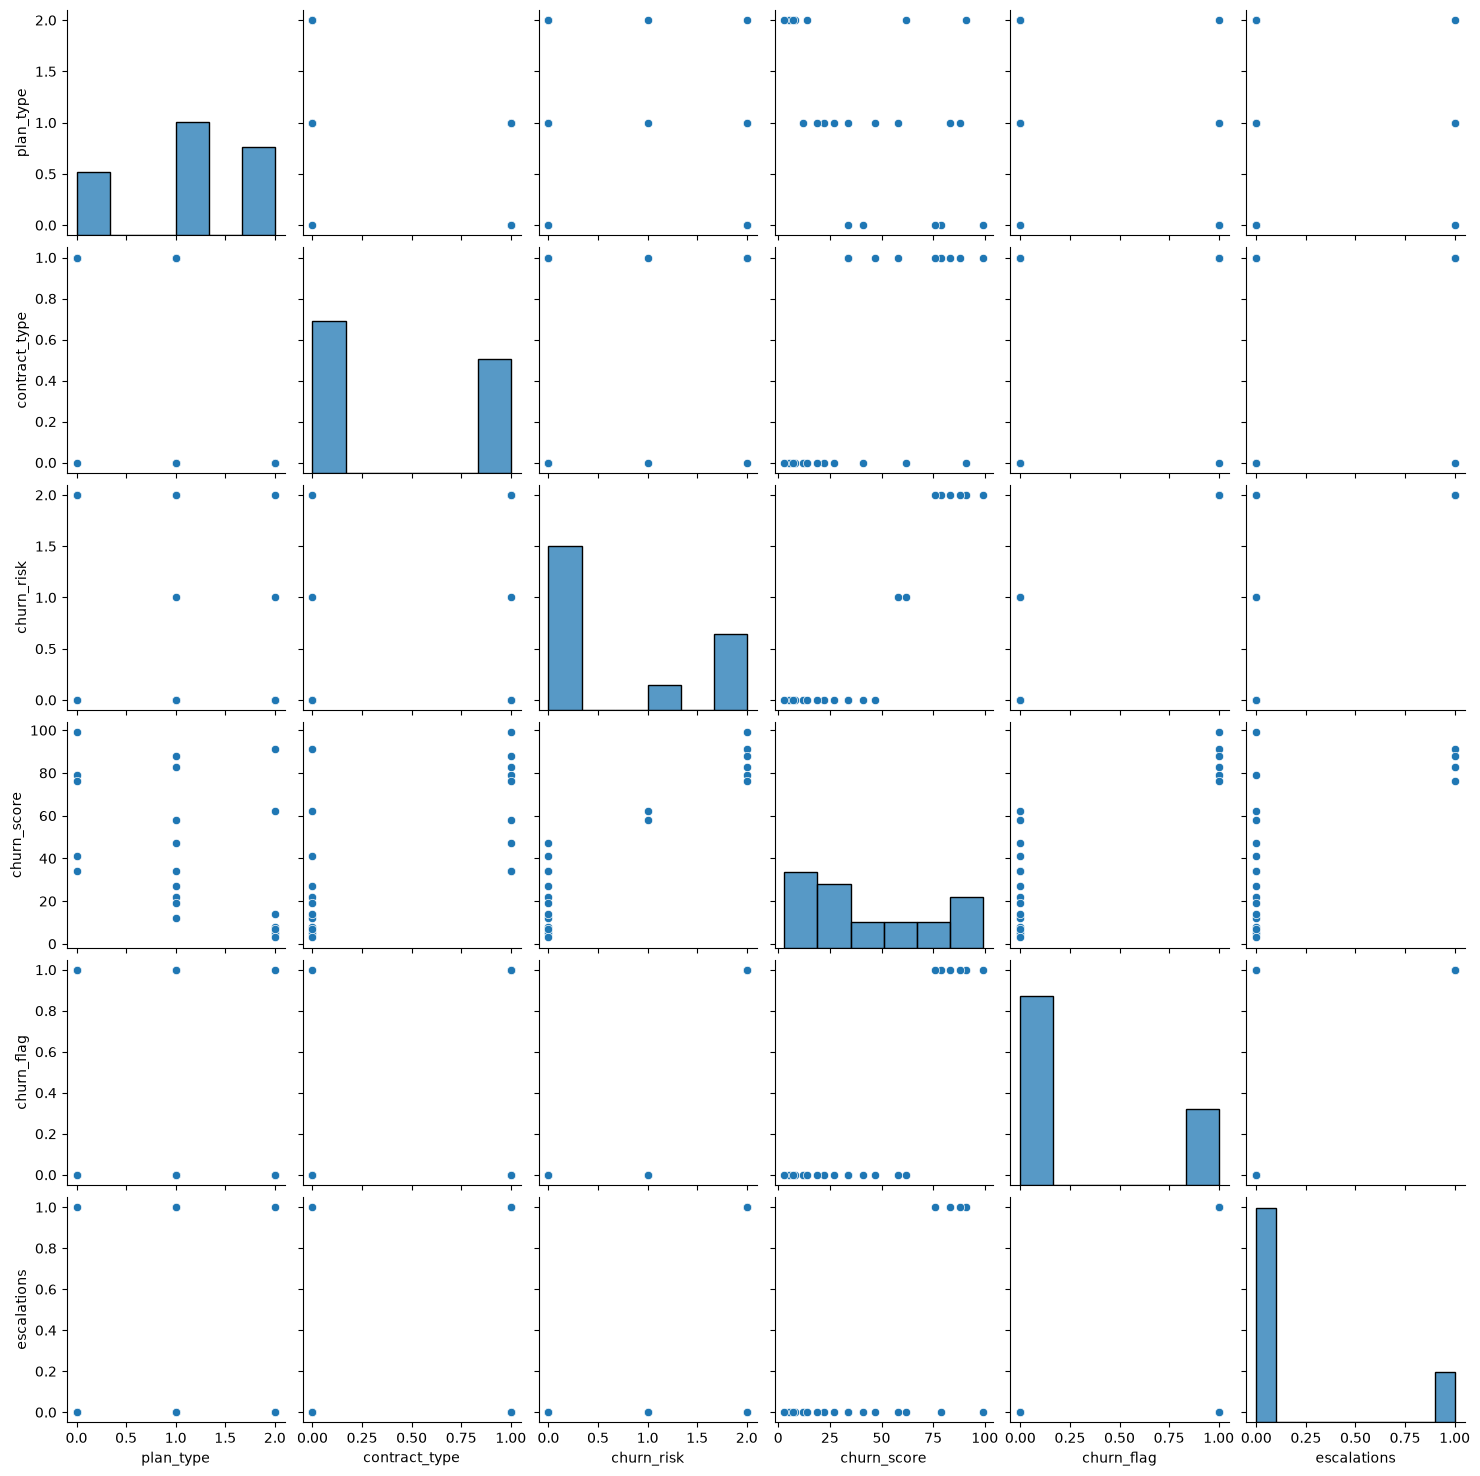

In [313]:
# pairplot
sns.pairplot(df_encoded)

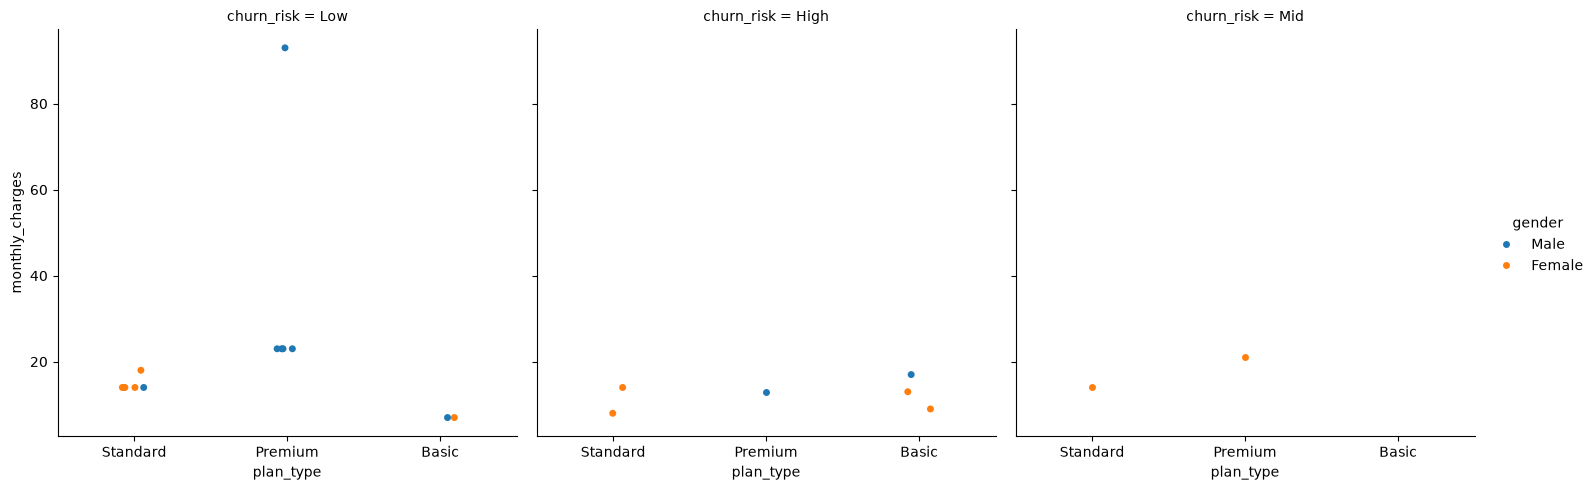

In [314]:
sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')
